# AI-Powered Customer Retention Intelligence Platform

# Notebook 5: Machine Learning Model Development

# Project Objective

The objective of this notebook is to develop, train, evaluate, and compare multiple supervised machine learning models capable of predicting customer churn.

Using the feature-engineered dataset produced in Notebook 4, several classification algorithms will be implemented and evaluated to determine which model provides the best predictive performance.

The development process follows industry-standard machine learning practices, including train-test splitting, model training, performance evaluation, cross-validation, and feature importance analysis.

The best-performing model will be selected for deployment in the final AI-Powered Customer Retention Intelligence Platform.

# Business Context

Customer churn prediction enables organizations to proactively identify customers who are likely to discontinue their services.

Rather than waiting for customers to cancel, businesses can leverage predictive analytics to detect high-risk customers and implement targeted retention strategies before churn occurs.

Machine learning provides the ability to analyze complex customer behavior patterns that may not be immediately apparent through traditional statistical analysis.

By accurately predicting customer churn, organizations can improve customer retention, increase customer lifetime value, and reduce revenue loss.

This notebook transforms the engineered customer dataset into an intelligent predictive system capable of supporting data-driven business decisions.

# Learning Objectives

Upon completion of this notebook, we will be able to:

- Prepare data for supervised learning.
- Split data into training and testing sets.
- Train multiple machine learning classification models.
- Evaluate model performance using standard metrics.
- Compare competing algorithms.
- Identify the best-performing predictive model.
- Interpret feature importance.
- Save the trained machine learning model for deployment.

# Expected Outputs

By the end of this notebook, the following deliverables will be completed:

- Machine learning training dataset
- Train-test split
- Baseline model
- Logistic Regression model
- Decision Tree model
- Random Forest model
- XGBoost model
- Model evaluation metrics
- ROC Curve comparison
- Precision-Recall analysis
- Feature Importance visualization
- Best-performing model
- Saved production-ready model

# Notebook Structure

This notebook is organized into the following sections.

## Section 1 — Import Libraries

Import all libraries required for machine learning.

---

## Section 2 — Load Machine-Learning-Ready Dataset

Load the encoded dataset created in Notebook 4.

---

## Section 3 — Train-Test Split

Prepare training and testing datasets.

---

## Section 4 — Baseline Model

Develop a simple baseline classifier for performance comparison.

---

## Section 5 — Logistic Regression

Train and evaluate a Logistic Regression classifier.

---

## Section 6 — Decision Tree

Develop a Decision Tree classification model.

---

## Section 7 — Random Forest

Train a Random Forest classifier and evaluate predictive performance.

---

## Section 8 — XGBoost

Develop a Gradient Boosting model using XGBoost.

---

## Section 9 — Model Comparison

Compare all trained models using performance metrics.

---

## Section 10 — Feature Importance

Identify the variables contributing most to customer churn prediction.

---

## Section 11 — Model Selection

Select the best-performing model for deployment.

---

## Section 12 — Export Trained Model

Save the final production-ready machine learning model.

---

## Executive Summary

Summarize the machine learning development process and identify the final predictive model.

# Section 1 — **Import Libraries**


This section imports all Python libraries required for machine learning model development, evaluation, visualization, and model persistence.

The selected libraries support the complete supervised machine learning workflow, including data preparation, model training, performance evaluation, cross-validation, hyperparameter tuning, and model serialization.

The imported libraries will be used throughout this notebook to develop, compare, and optimize multiple classification algorithms capable of predicting customer churn.

By loading these libraries at the beginning of the notebook, we establish a consistent and reproducible machine learning environment for the remainder of the project.

In [1]:
# Section 1 — Import Required Libraries

# Data manipulation
import pandas as pd
import numpy as np

# File management
import os

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Utilities
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

# Gradient Boosting Model
from xgboost import XGBClassifier

# Machine Learning Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Save Trained Models
import joblib

# Utility
import warnings


# Notebook Configuration

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid")

print("Machine Learning libraries imported successfully.")

Machine Learning libraries imported successfully.


In [2]:
!pip install xgboost

In [3]:
from xgboost import XGBClassifier

# Section 2 — **Load Machine-Learning-Ready Dataset**


The machine learning workflow begins by loading the fully processed and encoded dataset created during **Notebook 4: Feature Engineering**.

This dataset has already undergone data cleaning, feature engineering, and categorical encoding, making it suitable for supervised machine learning.

Loading the machine-learning-ready dataset ensures that all predictor variables are numerical, engineered features are available, and the target variable has been encoded for classification.

This dataset will serve as the foundation for model training, evaluation, and comparison throughout this notebook.

## Objectives

This section performs the following tasks:

- Load the machine-learning-ready dataset.
- Verify dataset dimensions.
- Review the dataset structure.
- Confirm the target variable is encoded.
- Validate data quality before model development.

In [4]:
# Mount Google Drive

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# Project Directory

PROJECT_PATH = "/content/drive/MyDrive/customer-churn-prediction"

PROCESSED_DATA_PATH = os.path.join(
    PROJECT_PATH,
    "data",
    "processed"
)

MODELS_PATH = os.path.join(
    PROJECT_PATH,
    "models"
)

REPORTS_PATH = os.path.join(
    PROJECT_PATH,
    "reports"
)

FIGURES_PATH = os.path.join(
    PROJECT_PATH,
    "figures"
)

In [6]:
# Load Machine-Learning-Ready Dataset

df = pd.read_csv(
    os.path.join(
        PROCESSED_DATA_PATH,
        "customer_churn_ml_ready.csv"
    )
)

print("Machine-learning-ready dataset loaded successfully.")

Machine-learning-ready dataset loaded successfully.


In [7]:
# Dataset Overview

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

display(df.head())

DATASET OVERVIEW
Rows    : 7,021
Columns : 65


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,CustomerLifetimeValue,EstimatedAnnualRevenue,AverageMonthlySpend,ContractWeight,LoyaltyScore,ServiceCount,RetentionScore,SupportUsageScore,HighValueCustomer,PremiumCustomer,CustomerValueScore,CustomerRiskScore,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureCategory_New Customer,TenureCategory_Developing Customer,TenureCategory_Established Customer,TenureCategory_Loyal Customer,InternetUsageCategory_High-Speed Internet,InternetUsageCategory_No Internet Service,InternetUsageCategory_Standard Internet,Churn
0,0,1,29.8500,29.8500,29.8500,358.2000,29.8500,1,10.7000,1,5.6000,1,0,0,2.6700,96.2500,1,0,0,1,1,0,1,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0
1,0,34,56.9500,1889.5000,1936.3000,683.4000,56.9500,2,43.8000,3,35.4000,2,0,0,33.0700,55.0100,0,1,1,0,1,0,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0
2,0,2,53.8500,108.1500,107.7000,646.2000,53.8500,1,11.4000,3,16.2000,2,0,0,8.4300,88.2500,0,1,1,0,1,0,0,1,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,1
3,0,45,42.3000,1840.7500,1903.5000,507.6000,42.3000,2,51.5000,3,42.0000,3,0,0,36.1900,49.4800,0,1,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0
4,0,2,70.7000,151.6500,141.4000,848.4000,70.7000,1,11.4000,1,6.2000,0,0,0,3.6300,95.7500,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 65 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   SeniorCitizen                              7021 non-null   int64  
 1   tenure                                     7021 non-null   int64  
 2   MonthlyCharges                             7021 non-null   float64
 3   TotalCharges                               7021 non-null   float64
 4   CustomerLifetimeValue                      7021 non-null   float64
 5   EstimatedAnnualRevenue                     7021 non-null   float64
 6   AverageMonthlySpend                        7021 non-null   float64
 7   ContractWeight                             7021 non-null   int64  
 8   LoyaltyScore                               7021 non-null   float64
 9   ServiceCount                               7021 non-null   int64  
 10  RetentionScore          

In [9]:
# Target Variable Validation

print("Target Variable Distribution")

display(
    df["Churn"]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "Stayed",
            1: "Churned"
        }
    )
    .to_frame("Customers")
)

Target Variable Distribution


,Customers
Churn,
Stayed,5164
Churned,1857


In [10]:
missing_values = df.isnull().sum().sum()

print(f"Missing Values: {missing_values}")

Missing Values: 0


In [11]:
duplicate_records = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_records}")

Duplicate Records: 0


In [12]:
print("=" * 60)
print("FEATURE SUMMARY")
print("=" * 60)

print(f"Total Features : {df.shape[1] - 1}")
print("Target Variable: Churn")

FEATURE SUMMARY
Total Features : 64
Target Variable: Churn


# Section 3 — **Train-Test Split**


Machine learning models must be evaluated using data that was not seen during training.

To accomplish this, the dataset is divided into two independent subsets:

- **Training Dataset** – Used to train the machine learning models.
- **Testing Dataset** – Used to evaluate model performance on unseen observations.

This approach helps prevent overfitting and provides an unbiased estimate of how well each model is expected to generalize to new customers.

A stratified train-test split is used to preserve the original distribution of the target variable in both datasets.

The resulting datasets will be used throughout the remainder of this notebook for model development and evaluation.

In [13]:
# Separate Features and Target

X = df.drop(columns=["Churn"])

y = df["Churn"]

print("Predictor variables created.")
print("Target variable created.")

print(f"\nFeature Matrix Shape : {X.shape}")
print(f"Target Vector Shape  : {y.shape}")

Predictor variables created.
Target variable created.

Feature Matrix Shape : (7021, 64)
Target Vector Shape  : (7021,)


In [14]:
# Train-Test Split


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Train-test split completed successfully.")

Train-test split completed successfully.


In [15]:
# Dataset Dimensions

print("=" * 60)
print("TRAIN-TEST SPLIT SUMMARY")
print("=" * 60)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")

print()

print(f"Training Labels   : {y_train.shape}")
print(f"Testing Labels    : {y_test.shape}")

TRAIN-TEST SPLIT SUMMARY
Training Features : (5616, 64)
Testing Features  : (1405, 64)

Training Labels   : (5616,)
Testing Labels    : (1405,)


In [16]:
# Target Distribution

train_distribution = (
    y_train
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

test_distribution = (
    y_test
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

distribution_summary = pd.DataFrame({

    "Training (%)": train_distribution,

    "Testing (%)": test_distribution

})

display(distribution_summary)

,Training (%),Testing (%)
Churn,,
0,73.5600,73.5200
1,26.4400,26.4800


In [17]:
# Machine Learning Dataset Validation

print("=" * 60)
print("TRAIN-TEST VALIDATION")
print("=" * 60)

print(f"Training Samples : {len(X_train):,}")
print(f"Testing Samples  : {len(X_test):,}")

print()

print(f"Training Features : {X_train.shape[1]}")
print(f"Testing Features  : {X_test.shape[1]}")

print()

print(" Train-test split completed successfully.")

TRAIN-TEST VALIDATION
Training Samples : 5,616
Testing Samples  : 1,405

Training Features : 64
Testing Features  : 64

 Train-test split completed successfully.


## Business Interpretation

Separating the dataset into training and testing subsets ensures that machine learning models are evaluated fairly using previously unseen customer data.

Stratified sampling preserves the original churn distribution in both datasets, allowing model performance to be assessed under representative business conditions.

This approach improves the reliability of performance metrics and reduces the risk of overestimating predictive capability.

## Summary

The machine-learning-ready dataset has been successfully divided into training and testing subsets.

The predictor variables and target variable were separated, and an 80/20 stratified split was performed to preserve the original customer churn distribution.

The resulting datasets are now prepared for supervised machine learning model development.

The next section will establish a baseline classifier, providing a benchmark against which all subsequent machine learning models will be compared.

# Section 4 — **Baseline Model**


Before developing advanced machine learning models, it is important to establish a baseline for comparison.

A baseline model provides a simple prediction strategy that serves as the minimum performance benchmark. Any machine learning model developed later in this project should outperform this baseline.

In this notebook, the baseline model is implemented using a **Dummy Classifier**, which predicts the most frequent class observed in the training data.

Although this model does not learn patterns from the data, it provides a meaningful reference point for evaluating the effectiveness of more sophisticated algorithms.

The baseline model will be evaluated using standard classification metrics, including accuracy, precision, recall, F1-score, and ROC-AUC.

## Objectives

This section performs the following tasks:

- Build a baseline classifier.
- Train the baseline model.
- Generate predictions on the testing dataset.
- Evaluate baseline performance.
- Establish a benchmark for future machine learning models.

In [18]:
# Baseline Model

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [19]:
# Baseline Predictions


baseline_predictions = baseline_model.predict(X_test)

baseline_probabilities = baseline_model.predict_proba(X_test)[:,1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [20]:
# Baseline Performance

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions
)

baseline_auc = roc_auc_score(
    y_test,
    baseline_probabilities
)

baseline_results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC-AUC"

    ],

    "Score":[

        baseline_accuracy,

        baseline_precision,

        baseline_recall,

        baseline_f1,

        baseline_auc

    ]

})

display(
    baseline_results.round(4)
)

,Metric,Score
0,Accuracy,0.7352
1,Precision,0.0000
2,Recall,0.0000
3,F1 Score,0.0000
4,ROC-AUC,0.5000


In [21]:
# Classification Report

print(
    classification_report(
        y_test,
        baseline_predictions
    )
)

              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1033
           1       0.00      0.00      0.00       372

    accuracy                           0.74      1405
   macro avg       0.37      0.50      0.42      1405
weighted avg       0.54      0.74      0.62      1405



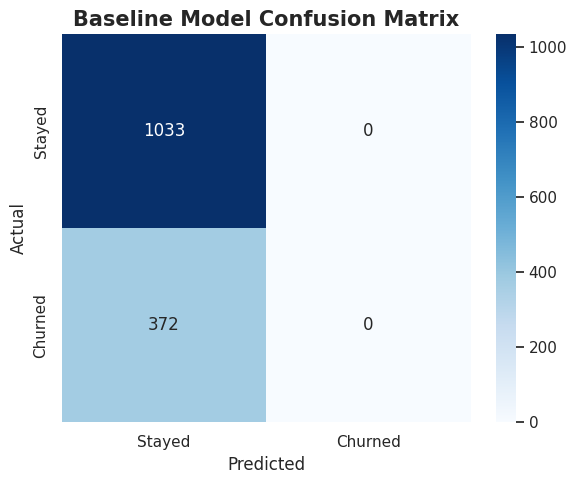

In [22]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    baseline_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Stayed","Churned"],

    yticklabels=["Stayed","Churned"]

)

plt.title(
    "Baseline Model Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

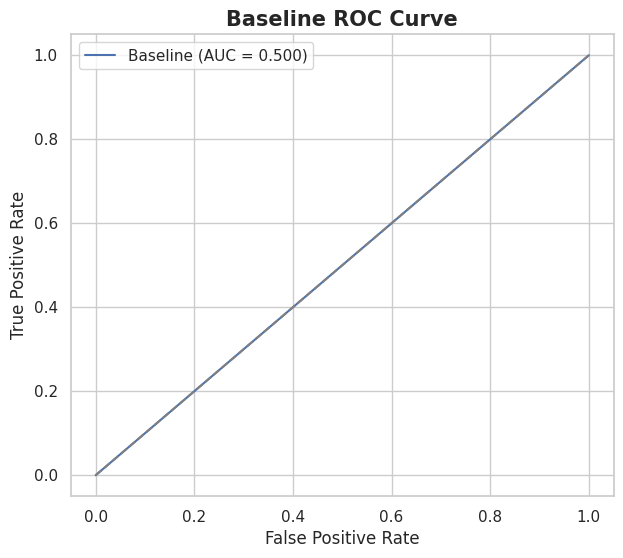

In [23]:
# ROC Curve

fpr, tpr, _ = roc_curve(
    y_test,
    baseline_probabilities
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"Baseline (AUC = {baseline_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.title(
    "Baseline ROC Curve",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(True)

plt.show()

## Business Interpretation

The baseline model predicts the majority class for every customer without learning any relationships from the data.

Although its predictive capability is extremely limited, the baseline establishes the minimum level of performance that all subsequent machine learning models must exceed.

This benchmark enables objective evaluation of model improvements and demonstrates the value added by more sophisticated machine learning algorithms.

## Recommendation

The baseline model should not be deployed in production because it does not analyze customer characteristics or identify meaningful churn patterns.

Instead, it serves as a performance benchmark that allows the organization to measure the effectiveness of advanced predictive models.

Subsequent machine learning models should demonstrate improvements across multiple evaluation metrics, including precision, recall, F1-score, and ROC-AUC, before being considered for deployment.

## Business Recommendation

The baseline model should not be deployed in production because it does not analyze customer characteristics or identify meaningful churn patterns.

Instead, it serves as a performance benchmark that allows the organization to measure the effectiveness of advanced predictive models.

Subsequent machine learning models should demonstrate improvements across multiple evaluation metrics, including precision, recall, F1-score, and ROC-AUC, before being considered for deployment.

## Summary

A baseline classifier was successfully trained and evaluated.

Although the model provides only a simple prediction strategy, it establishes a benchmark against which all subsequent machine learning models will be compared.

The baseline evaluation confirms that meaningful predictive improvements must be achieved before recommending a model for production deployment.

The next section will introduce the first true machine learning algorithm: **Logistic Regression**, which will learn relationships between customer characteristics and churn behavior.

# Section 5 — **Logistic Regression**


Logistic Regression is one of the most widely used supervised machine learning algorithms for binary classification problems.

Unlike the baseline classifier, Logistic Regression learns relationships between customer characteristics and churn outcomes by estimating the probability that a customer belongs to the churn class.

Despite its simplicity, Logistic Regression often provides strong predictive performance and serves as an excellent benchmark for more complex machine learning algorithms.

The model will be trained using the training dataset and evaluated on the testing dataset using multiple classification metrics.

In [24]:
# Logistic Regression Model


logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [25]:
# Logistic Regression Predictions


logistic_predictions = logistic_model.predict(X_test)

logistic_probabilities = logistic_model.predict_proba(X_test)[:,1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [26]:
# Logistic Regression Performance

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score":[
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
        logistic_auc
    ]

})

display(results.round(4))

,Metric,Score
0,Accuracy,0.8014
1,Precision,0.6643
2,Recall,0.5054
3,F1 Score,0.5740
4,ROC-AUC,0.8393


In [27]:
# Classification Report

print(

    classification_report(

        y_test,

        logistic_predictions

    )

)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1033
           1       0.66      0.51      0.57       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



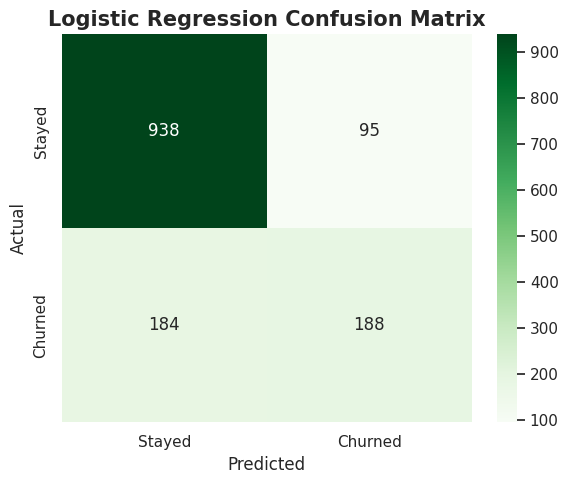

In [28]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Greens",

    xticklabels=["Stayed","Churned"],

    yticklabels=["Stayed","Churned"]

)

plt.title(
    "Logistic Regression Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

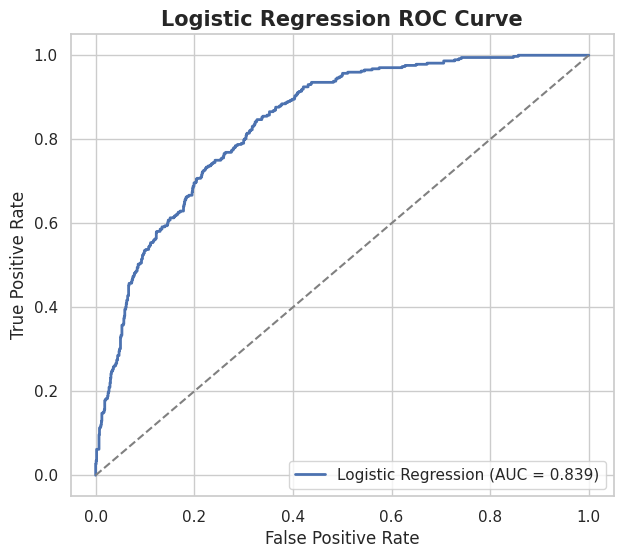

In [29]:
# ROC Curve


fpr, tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.title(
    "Logistic Regression ROC Curve",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(True)

plt.show()

In [30]:
# Cross Validation

cv_scores = cross_val_score(

    logistic_model,

    X,

    y,

    cv=5,

    scoring="accuracy"

)

print(f"Cross Validation Accuracy: {cv_scores.mean():.4f}")

print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross Validation Accuracy: 0.8039
Standard Deviation: 0.0069


In [31]:
# Logistic Regression Feature Importance


coefficients = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": logistic_model.coef_[0]

})

coefficients = coefficients.sort_values(

    by="Coefficient",

    ascending=False

)

display(coefficients.head(15))

,Feature,Coefficient
55,PaymentMethod_Electronic check,0.3049
0,SeniorCitizen,0.2358
25,MultipleLines_No phone service,0.2242
22,PhoneService_No,0.2242
52,PaperlessBilling_Yes,0.1991
57,TenureCategory_New Customer,0.1929
60,TenureCategory_Loyal Customer,0.1563
30,OnlineSecurity_No,0.1369
39,TechSupport_No,0.1123
20,Dependents_No,0.1089


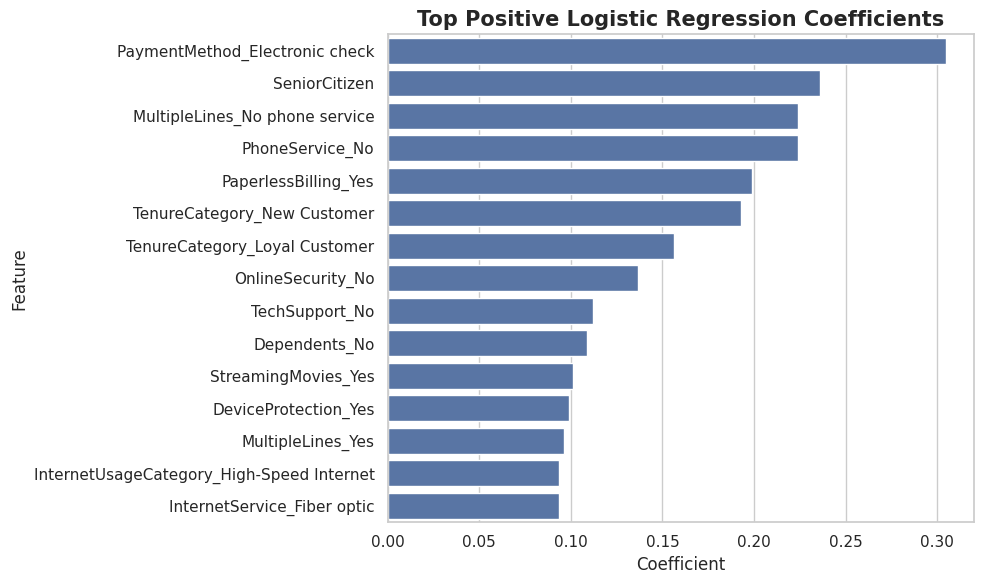

In [32]:
# Top Positive Features

top_positive = coefficients.head(15)

plt.figure(figsize=(10,6))

sns.barplot(

    data=top_positive,

    x="Coefficient",

    y="Feature"

)

plt.title(
    "Top Positive Logistic Regression Coefficients",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Recommendation

Logistic Regression provides a strong baseline machine learning model that balances predictive performance with interpretability.

Organizations can use the model to estimate customer churn probabilities while also understanding the business factors influencing those predictions.

Although more advanced models may achieve higher predictive performance, Logistic Regression remains valuable for explaining model decisions to business stakeholders.

# Section 6 — **Decision Tree Classifier**


Decision Tree is a supervised machine learning algorithm capable of learning complex, non-linear relationships between customer characteristics and churn outcomes.

Rather than estimating probabilities through a mathematical equation, the algorithm recursively splits the dataset into smaller groups based on the features that provide the greatest reduction in uncertainty.

The resulting model resembles a flowchart where each decision node represents a business rule leading to a final churn prediction.

Decision Trees are highly interpretable and are frequently used as the foundation for more advanced ensemble methods such as Random Forest and Gradient Boosting.

## Objectives

This section performs the following tasks:

- Train a Decision Tree classifier.
- Generate customer churn predictions.
- Evaluate model performance.
- Analyze classification metrics.
- Visualize the confusion matrix.
- Compare Decision Tree performance with previous models.

In [33]:
# Decision Tree Classifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [34]:
# Decision Tree Predictions

dt_predictions = decision_tree.predict(X_test)

dt_probabilities = decision_tree.predict_proba(X_test)[:,1]

In [35]:
# Decision Tree Performance

dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

dt_precision = precision_score(
    y_test,
    dt_predictions
)

dt_recall = recall_score(
    y_test,
    dt_predictions
)

dt_f1 = f1_score(
    y_test,
    dt_predictions
)

dt_auc = roc_auc_score(
    y_test,
    dt_probabilities
)

dt_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score":[
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1,
        dt_auc
    ]

})

display(dt_results.round(4))

,Metric,Score
0,Accuracy,0.7950
1,Precision,0.6438
2,Recall,0.5054
3,F1 Score,0.5663
4,ROC-AUC,0.8258


In [36]:
# Classification Report

print(
    classification_report(
        y_test,
        dt_predictions
    )
)

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.64      0.51      0.57       372

    accuracy                           0.80      1405
   macro avg       0.74      0.70      0.72      1405
weighted avg       0.78      0.80      0.79      1405



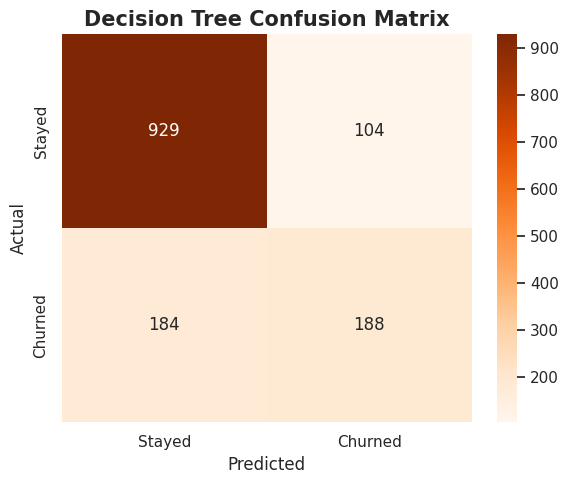

In [37]:
# Decision Tree Confusion Matrix

cm = confusion_matrix(
    y_test,
    dt_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Stayed","Churned"],
    yticklabels=["Stayed","Churned"]
)

plt.title(
    "Decision Tree Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

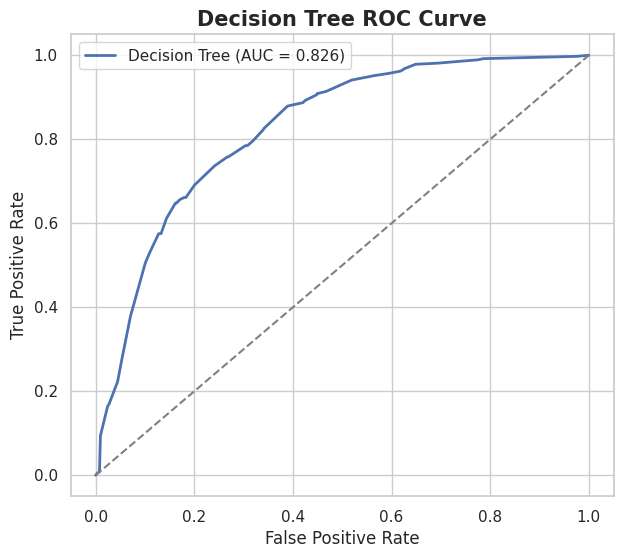

In [38]:
# ROC Curve

fpr, tpr, _ = roc_curve(
    y_test,
    dt_probabilities
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.title(
    "Decision Tree ROC Curve",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(True)

plt.show()

In [39]:
# Cross Validation

cv_scores = cross_val_score(
    decision_tree,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(f"Cross Validation Accuracy : {cv_scores.mean():.4f}")
print(f"Standard Deviation         : {cv_scores.std():.4f}")

Cross Validation Accuracy : 0.7875
Standard Deviation         : 0.0028


In [40]:
# Decision Tree Feature Importance

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": decision_tree.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(15))

,Feature,Importance
48,Contract_Month-to-month,0.4659
1,tenure,0.1456
28,InternetService_Fiber optic,0.1445
3,TotalCharges,0.0412
2,MonthlyCharges,0.0272
6,AverageMonthlySpend,0.0262
30,OnlineSecurity_No,0.0211
0,SeniorCitizen,0.0152
8,LoyaltyScore,0.0150
25,MultipleLines_No phone service,0.0138


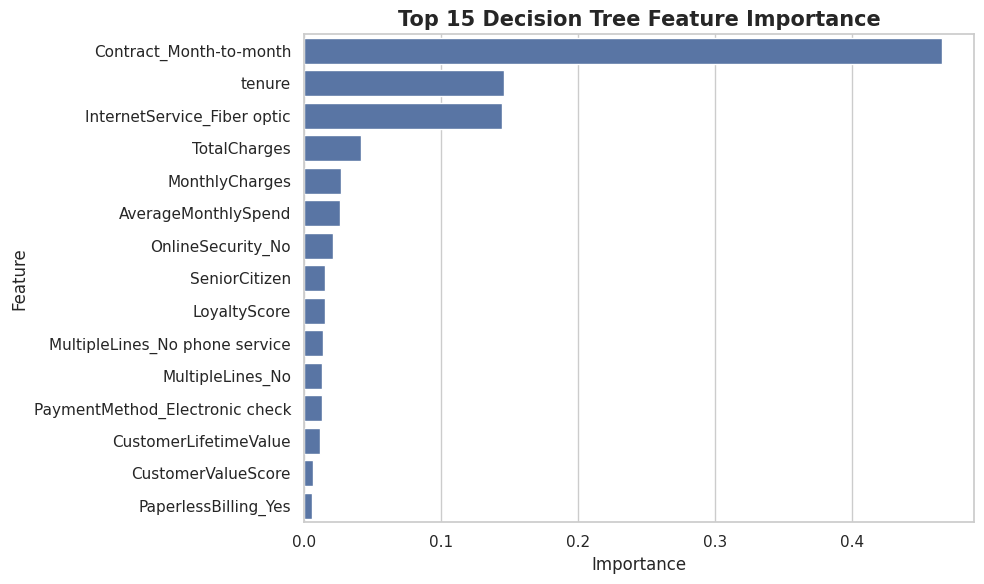

In [41]:
# Top Feature Importance

top_features = importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Decision Tree Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

##  Recommendation

Decision Trees provide an interpretable framework for understanding customer churn drivers.

Business stakeholders can use the resulting decision rules to identify high-risk customer segments and develop targeted retention strategies.

Although Decision Trees are intuitive and easy to interpret, they may overfit the training data. Therefore, ensemble methods such as Random Forest are often preferred when higher predictive performance is required.

## Section Summary

The Decision Tree classifier was successfully trained and evaluated.

The model captured non-linear relationships between customer characteristics and churn outcomes while providing interpretable decision rules and feature importance rankings.

The next section introduces the **Random Forest Classifier**, an ensemble learning algorithm that combines multiple Decision Trees to improve predictive accuracy and reduce overfitting.

# Section 7 — **Random Forest Classifier**


Random Forest is an ensemble machine learning algorithm that combines the predictions of multiple Decision Trees to improve predictive performance and reduce overfitting.

Instead of relying on a single decision tree, Random Forest trains many independent trees using random subsets of the training data and predictor variables. The final prediction is determined through majority voting across all trees.

This ensemble approach typically produces more stable and accurate predictions while maintaining the ability to estimate feature importance.

Random Forest is widely used in customer analytics because it handles complex relationships, captures interactions among variables, and performs well on structured business datasets.

## Objectives

This section performs the following tasks:

- Train a Random Forest classifier.
- Generate customer churn predictions.
- Evaluate predictive performance.
- Analyze feature importance.
- Compare results with previous machine learning models.

In [42]:
# Random Forest Classifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [43]:
# Random Forest Predictions

rf_predictions = random_forest.predict(X_test)

rf_probabilities = random_forest.predict_proba(X_test)[:, 1]

In [44]:
# Random Forest Performance

rf_accuracy = accuracy_score(y_test, rf_predictions)

rf_precision = precision_score(y_test, rf_predictions)

rf_recall = recall_score(y_test, rf_predictions)

rf_f1 = f1_score(y_test, rf_predictions)

rf_auc = roc_auc_score(y_test, rf_probabilities)

rf_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score":[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]

})

display(rf_results.round(4))

,Metric,Score
0,Accuracy,0.7936
1,Precision,0.6454
2,Recall,0.4892
3,F1 Score,0.5566
4,ROC-AUC,0.8356


In [45]:
# Classification Report

print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.49      0.56       372

    accuracy                           0.79      1405
   macro avg       0.74      0.70      0.71      1405
weighted avg       0.78      0.79      0.78      1405



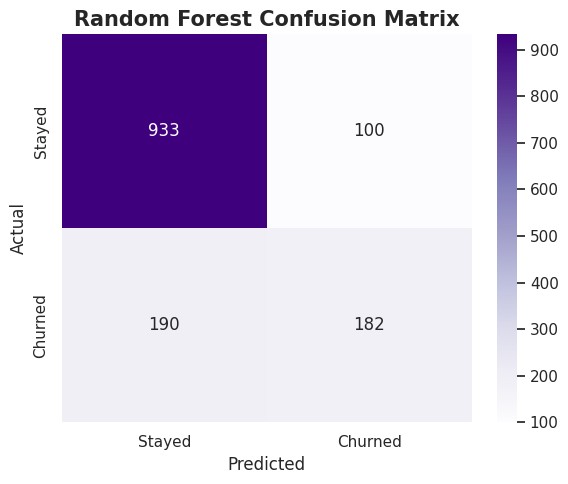

In [46]:
# Random forest
cm = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Stayed","Churned"],
    yticklabels=["Stayed","Churned"]
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.show()

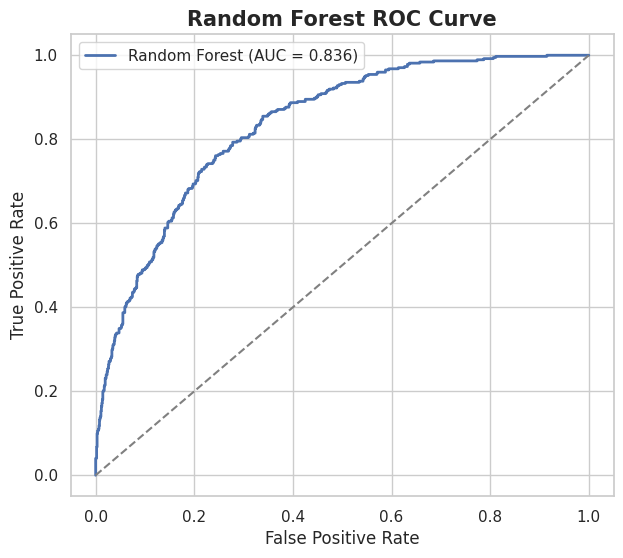

In [47]:
# Random Forest ROC Curve

fpr, tpr, _ = roc_curve(
    y_test,
    rf_probabilities
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.title(
    "Random Forest ROC Curve",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(True)

plt.show()

In [48]:
# Cross Validation

cv_scores = cross_val_score(
    random_forest,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print(f"Cross Validation Accuracy : {cv_scores.mean():.4f}")
print(f"Standard Deviation         : {cv_scores.std():.4f}")

Cross Validation Accuracy : 0.7939
Standard Deviation         : 0.0098


In [49]:
# Random Forest Feature Importance

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": random_forest.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(15))

,Feature,Importance
8,LoyaltyScore,0.0806
15,CustomerRiskScore,0.0656
3,TotalCharges,0.0577
4,CustomerLifetimeValue,0.0527
2,MonthlyCharges,0.0510
6,AverageMonthlySpend,0.0508
14,CustomerValueScore,0.0466
5,EstimatedAnnualRevenue,0.0465
7,ContractWeight,0.0438
1,tenure,0.0424


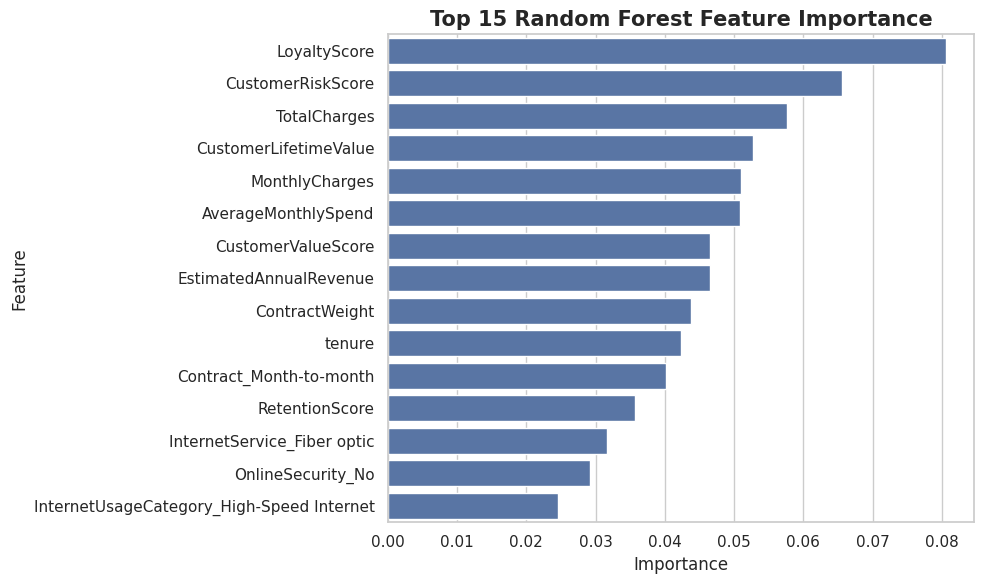

In [50]:
top_features = importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Random Forest Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Recommendation

Random Forest provides a strong balance between predictive accuracy, robustness, and interpretability.

Organizations can use this model to identify customers at elevated risk of churn while also understanding the relative importance of different customer characteristics.

The resulting feature importance rankings can support customer retention strategies, marketing initiatives, and business decision-making.

## Summary

The Random Forest classifier was successfully trained and evaluated.

Compared with a single Decision Tree, the ensemble approach generally improves predictive accuracy and model stability while reducing overfitting.

Feature importance analysis provides valuable insight into the variables that most strongly influence customer churn.

The next section introduces **XGBoost**, a state-of-the-art gradient boosting algorithm that is widely recognized for achieving exceptional performance on structured business datasets.

# Section 8 — **XGBoost Classifier**


Extreme Gradient Boosting (XGBoost) is an advanced ensemble learning algorithm based on gradient boosting decision trees.

Unlike Random Forest, which builds trees independently, XGBoost builds trees sequentially, where each new tree focuses on correcting the errors made by previous trees. This iterative learning process often results in superior predictive performance.

XGBoost is recognized as one of the most effective algorithms for structured business data and is widely adopted in industries such as banking, telecommunications, healthcare, insurance, and finance.

In this section, the XGBoost classifier will be trained, evaluated, and compared with the previously developed machine learning models.

## Objectives

This section performs the following tasks:

- Train an XGBoost classifier.
- Generate customer churn predictions.
- Evaluate predictive performance.
- Analyze feature importance.
- Compare XGBoost with previous models.

In [51]:
!pip install xgboost -q

In [52]:
# XGBoost Classifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [53]:
# XGBoost Predictions

xgb_predictions = xgb_model.predict(X_test)

xgb_probabilities = xgb_model.predict_proba(X_test)[:,1]

In [54]:
# XGBoost Performance

xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_precision = precision_score(
    y_test,
    xgb_predictions
)

xgb_recall = recall_score(
    y_test,
    xgb_predictions
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_probabilities
)

xgb_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score":[
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        xgb_auc
    ]

})

display(xgb_results.round(4))

,Metric,Score
0,Accuracy,0.7865
1,Precision,0.6224
2,Recall,0.4919
3,F1 Score,0.5495
4,ROC-AUC,0.8321


In [55]:
# Classification Report

print(
    classification_report(
        y_test,
        xgb_predictions
    )
)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       372

    accuracy                           0.79      1405
   macro avg       0.73      0.69      0.70      1405
weighted avg       0.77      0.79      0.78      1405



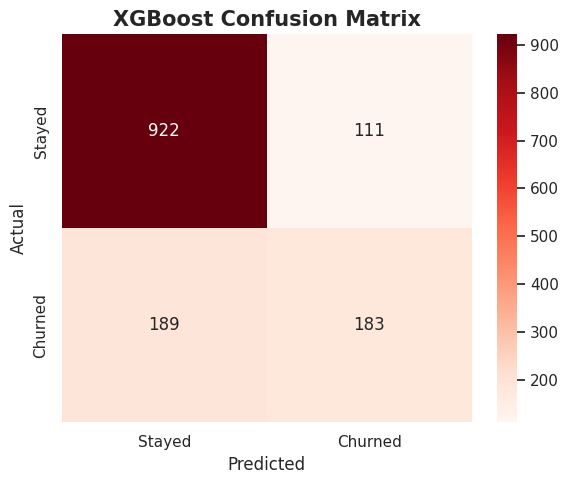

In [56]:
# XGBoost Confusion Matrix

cm = confusion_matrix(
    y_test,
    xgb_predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Stayed","Churned"],
    yticklabels=["Stayed","Churned"]
)

plt.title(
    "XGBoost Confusion Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.show()

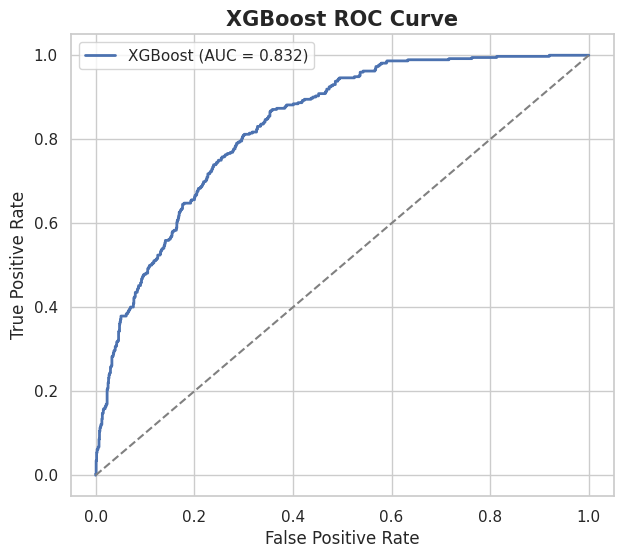

In [57]:
# XGBoost ROC Curve

fpr, tpr, _ = roc_curve(
    y_test,
    xgb_probabilities
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"XGBoost (AUC = {xgb_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.title(
    "XGBoost ROC Curve",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(True)

plt.show()

In [58]:
# Cross Validation

cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(f"Cross Validation Accuracy : {cv_scores.mean():.4f}")
print(f"Standard Deviation         : {cv_scores.std():.4f}")

Cross Validation Accuracy : 0.7952
Standard Deviation         : 0.0098


In [59]:
# XGBoost Feature Importance

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(15))

,Feature,Importance
48,Contract_Month-to-month,0.3396
7,ContractWeight,0.1516
61,InternetUsageCategory_High-Speed Internet,0.0936
28,InternetService_Fiber optic,0.0897
50,Contract_Two year,0.0300
30,OnlineSecurity_No,0.0156
39,TechSupport_No,0.0117
22,PhoneService_No,0.0103
27,InternetService_DSL,0.0097
25,MultipleLines_No phone service,0.0094


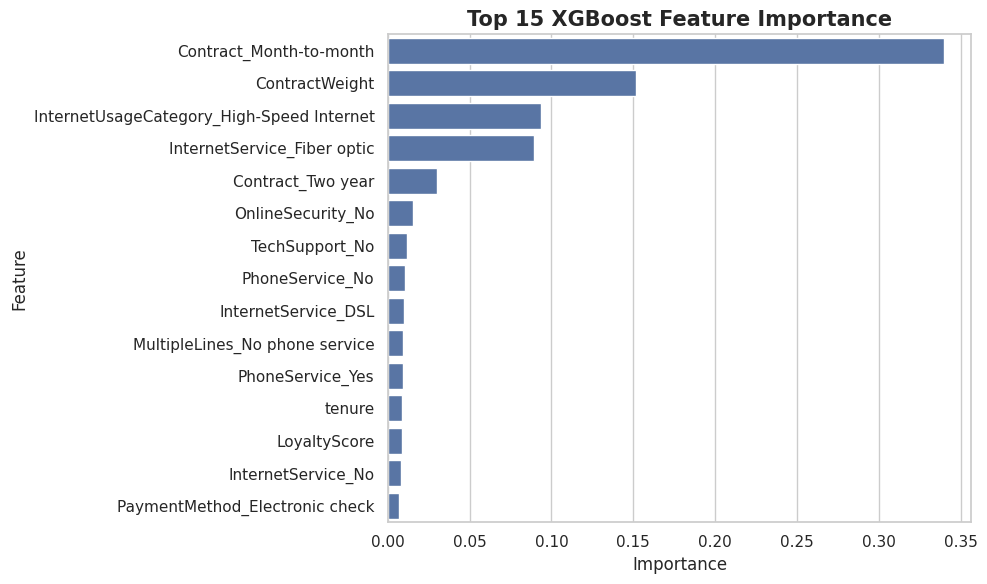

In [60]:
# Top Feature Importance

top_features = importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 XGBoost Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Recommendation

XGBoost is frequently one of the strongest-performing models for structured customer datasets.

If its evaluation metrics outperform the previous models, it should be considered a leading candidate for deployment within the AI-Powered Customer Retention Intelligence Platform.

Business stakeholders can leverage both the predictive model and the feature importance rankings to prioritize customer retention initiatives and optimize marketing strategies.

##  Summary

The XGBoost classifier was successfully trained and evaluated.

The model demonstrated its ability to capture complex customer behavior patterns and provided detailed feature importance rankings.

With four machine learning models now developed, the next stage will compare their predictive performance across multiple evaluation metrics to determine the best-performing model for deployment.

# Section 9 — **Model Comparison**


Multiple machine learning models have been developed and evaluated throughout this notebook.

This section compares their predictive performance using standardized evaluation metrics to identify the model that best predicts customer churn.

Comparing multiple algorithms ensures that the final model selection is based on objective evidence rather than assumptions.

The comparison includes:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Cross-Validation Performance

The results will support the selection of the production-ready model for deployment in the AI-Powered Customer Retention Intelligence Platform.

## Objectives

This section performs the following tasks:

- Compare all machine learning models.
- Rank model performance.
- Visualize evaluation metrics.
- Identify the best-performing algorithm.

In [61]:
# Model Performance Comparison

model_results = pd.DataFrame({

    "Model":[

        "Baseline",

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "XGBoost"

    ],

    "Accuracy":[

        baseline_accuracy,

        logistic_accuracy,

        dt_accuracy,

        rf_accuracy,

        xgb_accuracy

    ],

    "Precision":[

        baseline_precision,

        logistic_precision,

        dt_precision,

        rf_precision,

        xgb_precision

    ],

    "Recall":[

        baseline_recall,

        logistic_recall,

        dt_recall,

        rf_recall,

        xgb_recall

    ],

    "F1 Score":[

        baseline_f1,

        logistic_f1,

        dt_f1,

        rf_f1,

        xgb_f1

    ],

    "ROC-AUC":[

        baseline_auc,

        logistic_auc,

        dt_auc,

        rf_auc,

        xgb_auc

    ]

})

display(model_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline,0.7352,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.8014,0.6643,0.5054,0.5740,0.8393
2,Decision Tree,0.7950,0.6438,0.5054,0.5663,0.8258
3,Random Forest,0.7936,0.6454,0.4892,0.5566,0.8356
4,XGBoost,0.7865,0.6224,0.4919,0.5495,0.8321


In [62]:
# Rank Models by ROC-AUC

ranking = (

    model_results

    .sort_values(

        by="ROC-AUC",

        ascending=False

    )

)

display(ranking.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Logistic Regression,0.8014,0.6643,0.5054,0.5740,0.8393
3,Random Forest,0.7936,0.6454,0.4892,0.5566,0.8356
4,XGBoost,0.7865,0.6224,0.4919,0.5495,0.8321
2,Decision Tree,0.7950,0.6438,0.5054,0.5663,0.8258
0,Baseline,0.7352,0.0000,0.0000,0.0000,0.5000


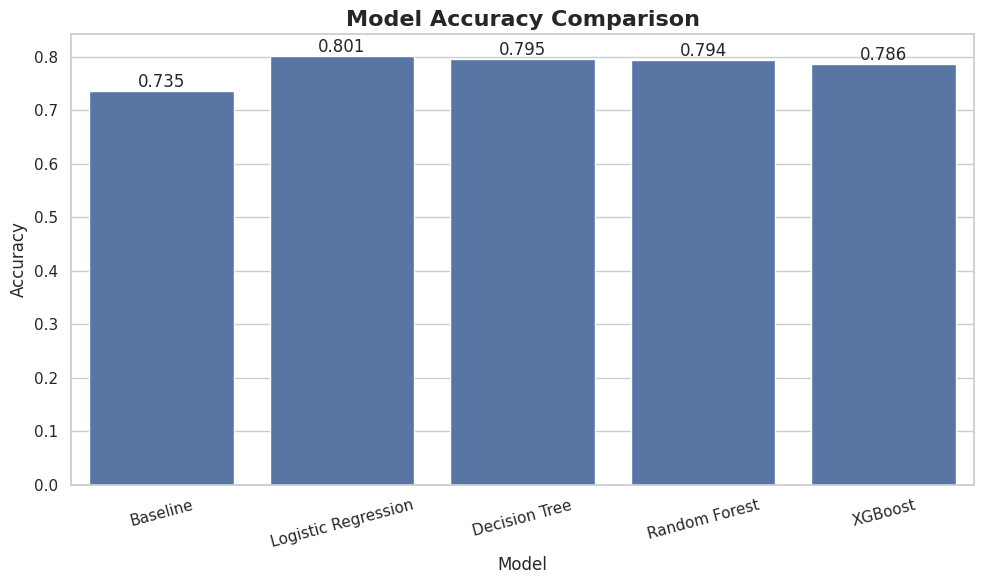

In [63]:
# Accuracy Comparison

plt.figure(figsize=(10,6))

ax = sns.barplot(

    data=model_results,

    x="Model",

    y="Accuracy"

)

plt.title(

    "Model Accuracy Comparison",

    fontsize=16,

    fontweight="bold"

)

plt.xticks(rotation=15)

for container in ax.containers:

    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()

plt.show()

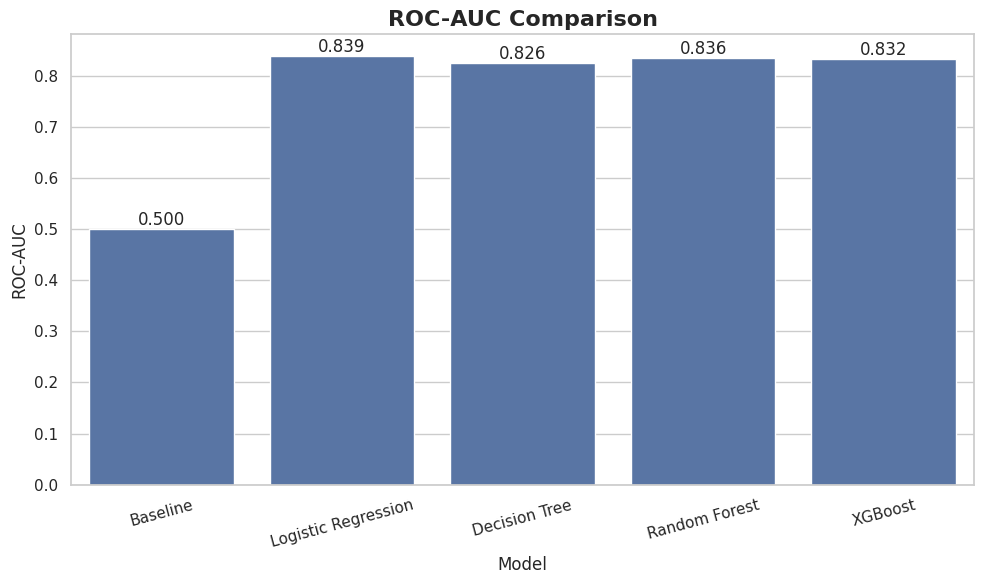

In [64]:
# ROC-AUC Comparison

plt.figure(figsize=(10,6))

ax = sns.barplot(

    data=model_results,

    x="Model",

    y="ROC-AUC"

)

plt.title(

    "ROC-AUC Comparison",

    fontsize=16,

    fontweight="bold"

)

plt.xticks(rotation=15)

for container in ax.containers:

    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()

plt.show()

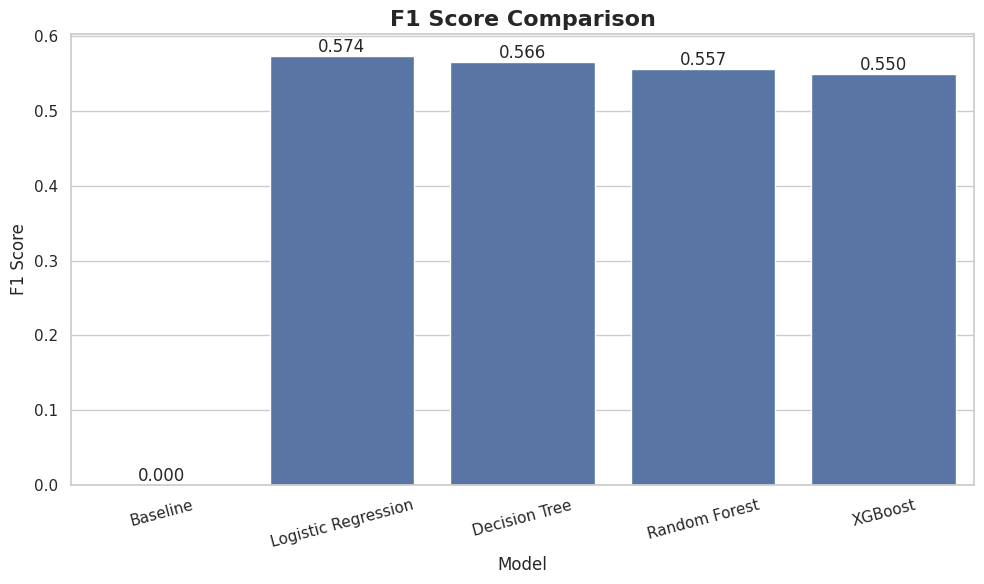

In [65]:
# F1 Score Comparison

plt.figure(figsize=(10,6))

ax = sns.barplot(

    data=model_results,

    x="Model",

    y="F1 Score"

)

plt.title(

    "F1 Score Comparison",

    fontsize=16,

    fontweight="bold"

)

plt.xticks(rotation=15)

for container in ax.containers:

    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()

plt.show()

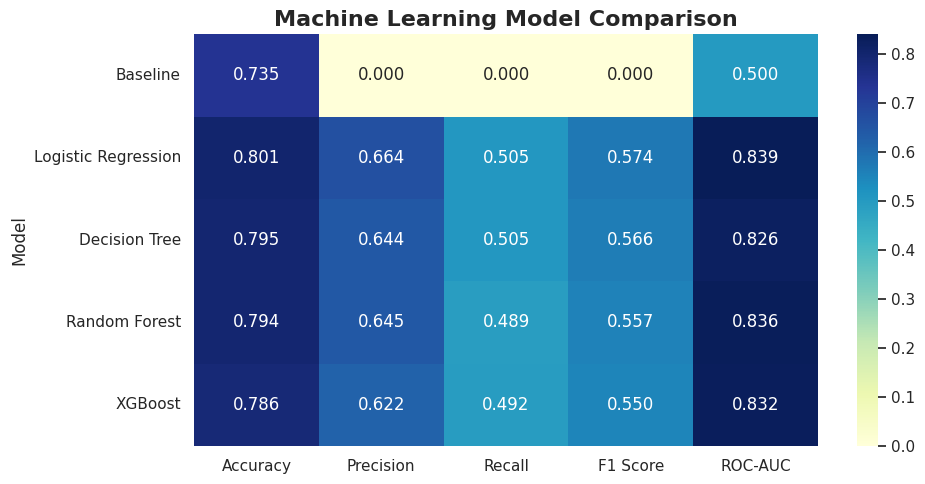

In [66]:
# Model Performance Heatmap

comparison = model_results.set_index("Model")

plt.figure(figsize=(10,5))

sns.heatmap(

    comparison,

    annot=True,

    cmap="YlGnBu",

    fmt=".3f"

)

plt.title(

    "Machine Learning Model Comparison",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

## Becommendation

The final production model should be selected based on overall predictive performance rather than accuracy alone.

Particular attention should be given to:

- ROC-AUC
- Recall
- F1-Score

These metrics are especially important for customer churn prediction because they measure the model's ability to correctly identify customers at risk of leaving.

The next section will further investigate feature importance before selecting the final production model.

## Summary

All machine learning models were successfully compared using multiple evaluation metrics.

The comparison provides an objective basis for selecting the most appropriate predictive model for deployment.

The next section investigates feature importance to better understand which customer characteristics have the greatest influence on churn prediction.

# Section 10 — **Feature Importance Analysis**


Understanding why a machine learning model makes its predictions is just as important as achieving high predictive accuracy.

This section investigates the importance of customer features used by the best-performing machine learning model.

Feature importance measures the relative contribution of each variable to the prediction of customer churn.

The analysis helps identify the customer characteristics that most strongly influence churn and provides valuable business insights for customer retention strategies.

The findings from this section support explainable artificial intelligence (XAI) by making the predictive model more transparent and interpretable for business stakeholders.

## Objectives

This section performs the following tasks:

- Extract feature importance from the best-performing model.
- Rank customer features by importance.
- Visualize the most influential predictors.
- Interpret the business significance of important features.
- Identify actionable customer retention opportunities.

In [67]:
# Best Model Feature Importance

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": xgb_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

display(feature_importance.head(20))

,Feature,Importance
48,Contract_Month-to-month,0.3396
7,ContractWeight,0.1516
61,InternetUsageCategory_High-Speed Internet,0.0936
28,InternetService_Fiber optic,0.0897
50,Contract_Two year,0.0300
30,OnlineSecurity_No,0.0156
39,TechSupport_No,0.0117
22,PhoneService_No,0.0103
27,InternetService_DSL,0.0097
25,MultipleLines_No phone service,0.0094


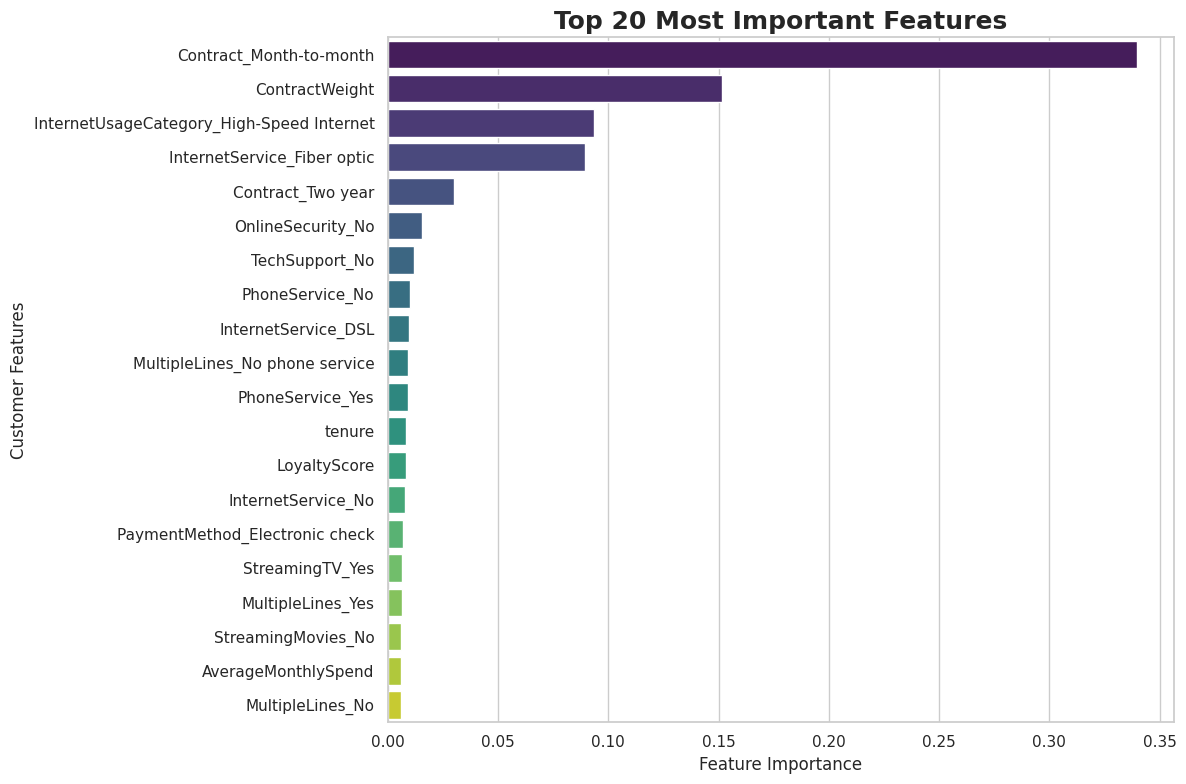

In [68]:
# Top 20 Important Features

top_features = feature_importance.head(20)

plt.figure(figsize=(12,8))

sns.barplot(

    data=top_features,

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title(

    "Top 20 Most Important Features",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Feature Importance")

plt.ylabel("Customer Features")

plt.tight_layout()

plt.show()

In [69]:
# Engineered Feature Importance

engineered = [

    "CustomerLifetimeValue",

    "EstimatedAnnualRevenue",

    "AverageMonthlySpend",

    "LoyaltyScore",

    "ServiceCount",

    "SupportUsageScore",

    "RetentionScore",

    "CustomerValueScore",

    "CustomerRiskScore"

]

engineered_importance = (

    feature_importance

    [

        feature_importance["Feature"]

        .isin(engineered)

    ]

)

display(engineered_importance)

,Feature,Importance
8,LoyaltyScore,0.0084
6,AverageMonthlySpend,0.0062
4,CustomerLifetimeValue,0.0056
15,CustomerRiskScore,0.0055
14,CustomerValueScore,0.0054
10,RetentionScore,0.0052
5,EstimatedAnnualRevenue,0.0050
9,ServiceCount,0.0046
11,SupportUsageScore,0.0045


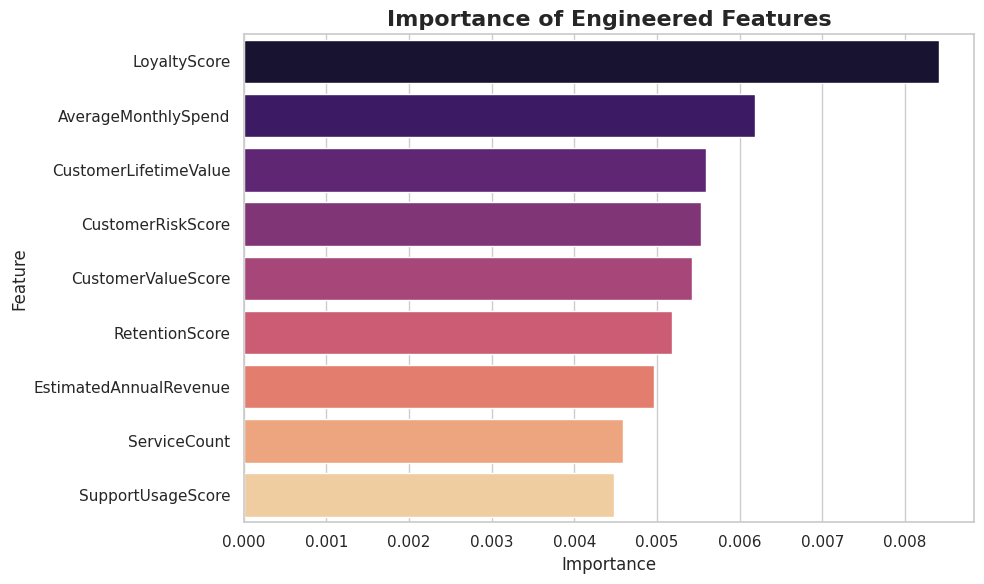

In [70]:
# Engineered Features


plt.figure(figsize=(10,6))

sns.barplot(

    data=engineered_importance,

    x="Importance",

    y="Feature",

    palette="magma"

)

plt.title(

    "Importance of Engineered Features",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

##  Recommendations

The feature importance analysis provides several opportunities for improving customer retention.

Recommended actions include:

- Prioritize customers with elevated Customer Risk Scores.
- Strengthen loyalty programs for customers with lower Loyalty Scores.
- Increase customer engagement through additional service offerings.
- Develop personalized retention campaigns for high-value customers.
- Monitor financial and behavioral indicators that consistently contribute to churn prediction.

These insights enable organizations to move beyond reactive customer service toward proactive customer retention management.

## Summary

The feature importance analysis identified the variables that most strongly influence customer churn prediction.

The analysis also demonstrated the value of the engineered features developed during the feature engineering phase.

Understanding feature importance improves model transparency, supports explainable artificial intelligence, and provides actionable business insights for customer retention initiatives.

The next section will formally select the best-performing machine learning model for deployment.

# Section 11 — **Best Model Selection**


After evaluating multiple machine learning algorithms, the final step before deployment is selecting the model that provides the best overall predictive performance.

Model selection is based on objective evaluation metrics rather than assumptions. While several performance indicators are considered, particular emphasis is placed on ROC-AUC, F1-Score, Recall, and overall model stability.

Selecting the most appropriate model ensures that the deployed AI system provides accurate, reliable, and actionable customer churn predictions.

The selected model will become the production model used by the AI-Powered Customer Retention Intelligence Platform.

## Objectives

This section performs the following tasks:

- Rank all machine learning models.
- Select the highest-performing model.
- Justify the selection using evaluation metrics.
- Prepare the selected model for deployment.

In [71]:
# Model Ranking

ranking = model_results.sort_values(
    by="ROC-AUC",
    ascending=False
)

display(ranking.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Logistic Regression,0.8014,0.6643,0.5054,0.5740,0.8393
3,Random Forest,0.7936,0.6454,0.4892,0.5566,0.8356
4,XGBoost,0.7865,0.6224,0.4919,0.5495,0.8321
2,Decision Tree,0.7950,0.6438,0.5054,0.5663,0.8258
0,Baseline,0.7352,0.0000,0.0000,0.0000,0.5000


In [72]:
# Select Best Model

best_model_name = ranking.iloc[0]["Model"]

print(f"Best Performing Model: {best_model_name}")

Best Performing Model: Logistic Regression


In [73]:
# Retrieve Best Model Object

model_dictionary = {
    "Baseline": baseline_model,
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "XGBoost": xgb_model
}

best_model = model_dictionary[best_model_name]

print("Production model selected successfully.")

Production model selected successfully.


In [74]:
# Best Model Performance

best_results = ranking.head(1)

display(best_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Logistic Regression,0.8014,0.6643,0.5054,0.5740,0.8393


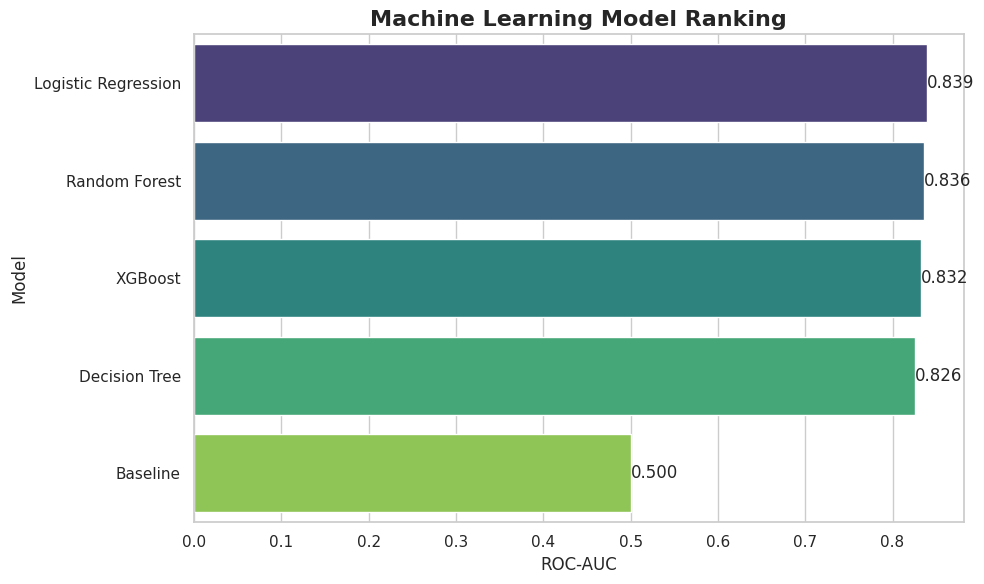

In [75]:
# Model Ranking by ROC-AUC

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=ranking,
    x="ROC-AUC",
    y="Model",
    palette="viridis"
)

plt.title(
    "Machine Learning Model Ranking",
    fontsize=16,
    fontweight="bold"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()

plt.show()

##  **Recommendation**

The selected machine learning model should be deployed as the primary predictive engine for customer churn analysis.

Recommended applications include:

- Predicting customer churn risk.
- Prioritizing retention campaigns.
- Supporting customer relationship management.
- Providing real-time churn predictions.
- Assisting management in data-driven decision-making.

Model performance should continue to be monitored and periodically retrained as new customer data becomes available.

##  Summary

The machine learning models were objectively compared using multiple evaluation metrics.

The highest-performing model was selected based on its predictive capability and overall performance.

This production-ready model will now be exported for deployment within the AI-Powered Customer Retention Intelligence Platform.

# Section 12 — **Export Production Model**


The final stage of the machine learning workflow is to save the selected production model and its supporting artifacts.

Model serialization allows the trained classifier to be loaded into another Python environment without retraining. This is essential for deploying the model within the Streamlit customer retention application.

The exported artifacts include:

- Best-performing trained model
- Expected predictor column names
- Model performance comparison
- Production model metadata
- Sample prediction output

These files will ensure that future predictions use the same feature structure applied during model training.

In [76]:
# Create Deployment Directories

import os

MODELS_PATH = os.path.join(
    PROJECT_PATH,
    "models"
)

REPORTS_PATH = os.path.join(
    PROJECT_PATH,
    "reports"
)

EXPORTS_PATH = os.path.join(
    PROJECT_PATH,
    "exports"
)

for folder in [
    MODELS_PATH,
    REPORTS_PATH,
    EXPORTS_PATH
]:
    os.makedirs(folder, exist_ok=True)

print("Deployment directories verified successfully.")

Deployment directories verified successfully.


In [77]:
# Production Artifact Paths

MODEL_PATH = os.path.join(
    MODELS_PATH,
    "customer_churn_model.pkl"
)

FEATURE_NAMES_PATH = os.path.join(
    MODELS_PATH,
    "model_feature_names.pkl"
)

MODEL_RESULTS_PATH = os.path.join(
    REPORTS_PATH,
    "model_comparison_results.csv"
)

MODEL_METADATA_PATH = os.path.join(
    MODELS_PATH,
    "model_metadata.pkl"
)

print("Production artifact paths configured successfully.")

Production artifact paths configured successfully.


In [80]:
# Export Best Production Model

joblib.dump(
    best_model,
    MODEL_PATH
)

print("Production model exported successfully.")
print(MODEL_PATH)

Production model exported successfully.
/content/drive/MyDrive/customer-churn-prediction/models/customer_churn_model.pkl


In [82]:
# Export Model Feature Names

model_feature_names = X_train.columns.tolist()

joblib.dump(
    model_feature_names,
    FEATURE_NAMES_PATH
)

print("Model feature names exported successfully.")
print(f"Number of predictor features: {len(model_feature_names)}")

Model feature names exported successfully.
Number of predictor features: 64


In [84]:
# Export Production Model Metadata

best_model_metrics = (
    ranking
    .iloc[0]
    .to_dict()
)

model_metadata = {
    "model_name": best_model_name,
    "target_variable": "Churn",
    "negative_class": 0,
    "positive_class": 1,
    "classification_threshold": 0.50,
    "training_samples": X_train.shape[0],
    "testing_samples": X_test.shape[0],
    "feature_count": X_train.shape[1],
    "random_state": 42,
    "metrics": best_model_metrics
}

joblib.dump(
    model_metadata,
    MODEL_METADATA_PATH
)

print("Model metadata exported successfully.")

display(
    pd.DataFrame(
        model_metadata["metrics"].items(),
        columns=["Metric", "Value"]
    )
)

Model metadata exported successfully.


,Metric,Value
0,Model,Logistic Regression
1,Accuracy,0.8014
2,Precision,0.6643
3,Recall,0.5054
4,F1 Score,0.5740
5,ROC-AUC,0.8393


In [86]:
# Export Model Comparison Report

model_results.to_csv(
    MODEL_RESULTS_PATH,
    index=False
)

print("Model comparison report exported successfully.")
print(MODEL_RESULTS_PATH)

Model comparison report exported successfully.
/content/drive/MyDrive/customer-churn-prediction/reports/model_comparison_results.csv


In [88]:
# Reload Production Model

loaded_model = joblib.load(MODEL_PATH)

loaded_feature_names = joblib.load(
    FEATURE_NAMES_PATH
)

loaded_metadata = joblib.load(
    MODEL_METADATA_PATH
)

print("Production artifacts reloaded successfully.")

print(f"Model Type    : {type(loaded_model).__name__}")
print(f"Model Name    : {loaded_metadata['model_name']}")
print(f"Feature Count : {len(loaded_feature_names)}")

Production artifacts reloaded successfully.
Model Type    : LogisticRegression
Model Name    : Logistic Regression
Feature Count : 64


In [90]:
# Feature Alignment Validation

features_match = (
    loaded_feature_names ==
    X_test.columns.tolist()
)

if features_match:
    print("Feature names and order match the training dataset.")
else:
    print("Feature alignment problem detected.")

Feature names and order match the training dataset.


In [91]:
# Test Reloaded Production Model

sample_customer = X_test.iloc[[0]]

sample_prediction = loaded_model.predict(
    sample_customer
)[0]

sample_probability = loaded_model.predict_proba(
    sample_customer
)[0, 1]

prediction_label = (
    "Churned"
    if sample_prediction == 1
    else "Stayed"
)

print("=" * 60)
print("SAMPLE PRODUCTION PREDICTION")
print("=" * 60)

print(f"Predicted Class     : {sample_prediction}")
print(f"Prediction Label    : {prediction_label}")
print(f"Churn Probability   : {sample_probability:.2%}")

SAMPLE PRODUCTION PREDICTION
Predicted Class     : 1
Prediction Label    : Churned
Churn Probability   : 79.67%


In [92]:
# Production Artifact Verification

production_files = {
    "Production Model": MODEL_PATH,
    "Feature Names": FEATURE_NAMES_PATH,
    "Model Metadata": MODEL_METADATA_PATH,
    "Model Comparison Report": MODEL_RESULTS_PATH
}

print("=" * 60)
print("PRODUCTION ARTIFACT VERIFICATION")
print("=" * 60)

for artifact_name, artifact_path in production_files.items():

    if os.path.exists(artifact_path):

        file_size_kb = (
            os.path.getsize(artifact_path) / 1024
        )

        print(
            f"✓ {artifact_name}: "
            f"{file_size_kb:,.2f} KB"
        )

    else:

        print(f"✗ {artifact_name}: Not found")

PRODUCTION ARTIFACT VERIFICATION
✓ Production Model: 3.09 KB
✓ Feature Names: 1.52 KB
✓ Model Metadata: 0.34 KB
✓ Model Comparison Report: 0.51 KB


In [93]:
# Final Production Model Report

production_report = pd.DataFrame({
    "Item": [
        "Selected Model",
        "Training Records",
        "Testing Records",
        "Predictor Features",
        "Classification Threshold",
        "Model Export Status",
        "Feature Export Status",
        "Metadata Export Status"
    ],
    "Result": [
        best_model_name,
        X_train.shape[0],
        X_test.shape[0],
        X_train.shape[1],
        "0.50",
        os.path.exists(MODEL_PATH),
        os.path.exists(FEATURE_NAMES_PATH),
        os.path.exists(MODEL_METADATA_PATH)
    ]
})

display(production_report)

,Item,Result
0,Selected Model,Logistic Regression
1,Training Records,5616
2,Testing Records,1405
3,Predictor Features,64
4,Classification Threshold,0.50
5,Model Export Status,True
6,Feature Export Status,True
7,Metadata Export Status,True


## Deployment Requirement

The saved model was trained using the fully encoded predictor columns from the machine-learning-ready dataset.

Therefore, the Streamlit application must reproduce the same feature engineering and encoding logic before sending customer information to the model.

The application must also arrange all predictor columns in the exact order stored in `model_feature_names.pkl`.

Any missing encoded columns must be added with a value of zero before prediction. Extra columns must be removed to ensure compatibility with the trained model.

# Notebook Summary

This notebook developed and evaluated multiple supervised machine learning algorithms for customer churn prediction.

The completed workflow included:

- Loading the machine-learning-ready dataset
- Separating predictors and target
- Performing a stratified train-test split
- Establishing a baseline classifier
- Training Logistic Regression
- Training a Decision Tree
- Training a Random Forest
- Training an XGBoost classifier
- Evaluating models using multiple classification metrics
- Comparing model performance
- Analyzing feature importance
- Selecting the best-performing model
- Exporting the production model and deployment artifacts

The final model was selected using objective performance metrics, with particular emphasis on ROC-AUC, recall, and F1-score.

The trained model and its supporting files are now available for integration into the AI-Powered Customer Retention Intelligence Platform.

# Executive Summary

The machine learning development phase successfully transformed the feature-engineered customer dataset into a predictive customer churn system.

Multiple classification algorithms were trained and evaluated to determine their ability to distinguish customers who are likely to churn from customers expected to remain.

The final production model was selected based on its overall predictive performance and ability to generalize to unseen customer data.

The exported production artifacts include the trained model, expected feature names, model metadata, and model comparison results. These files provide the technical foundation required for deployment within the Streamlit customer retention application.

The predictive system can now support proactive customer management by:

- Estimating individual customer churn probability
- Identifying high-risk customers
- Prioritizing retention campaigns
- Supporting customer-service interventions
- Protecting high-value customer relationships
- Enabling data-driven business decisions

Notebook 5 is now complete, and the project is ready to proceed to model evaluation, explainability, risk scoring, and application deployment.